<h2 align="center">📊 Create Visuals & Generate Business Insights</h2>

<p align="center">
  <b>Analyze the data, create meaningful visualizations, and uncover actionable business insights.</b>
</p>

<hr>

### 🎯 Objective

For the requested business questions, we will:

- 📊 **Create appropriate visualizations** to clearly represent the data.
- 🔍 **Analyze the results** and identify important patterns and trends.
- 💡 **Generate actionable business insights** based on the findings.
- 📈 **Compare campaign, product, store, and promotion performance** where applicable.

### 📌 Analysis Approach

```text
Business Question
       │
       ▼
🔍 Prepare & Filter Data
       │
       ▼
📊 Create Visualization
       │
       ▼
📈 Analyze Results
       │
       ▼
💡 Generate Insights
       │
       ▼
🎯 Business Recommendation

## ** 1. Store Distribution Across Cities**

Visualize the **number of stores in each city** to understand the geographical distribution of stores.

###  Objective

In this analysis, we will:

-  Count the total number of stores in each city.
-  Create a **bar chart** to visualize the store distribution.
-  Identify the city with the **highest number of stores**.
-  Compare the number of stores across all other cities.
-  Specifically compare **Bengaluru** with **Hyderabad** and **Chennai**.

### ** Key Questions**

- **Which city has the most stores?**
- **How are the stores distributed across the other cities?**
- **How does the number of stores in Bengaluru compare with Hyderabad and Chennai?**

> ** Hint:** Use a **bar chart** to visualize the number of stores by city.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df_camp = pd.read_csv(r"C:\Users\Abhinay A\Desktop\resources_2\datasets\dim_campaigns.csv")
df_camp

,campaign_id,campaign_name,start_date,end_date
0,CAMP_DIW_01,Diwali,12-11-2023,18-11-2023
1,CAMP_SAN_01,Sankranti,10-01-2024,16-01-2024


In [4]:
df_pro = pd.read_csv(r"C:\Users\Abhinay A\Desktop\resources_2\datasets\dim_products.csv")
df_pro.head(2)

,product_code,product_name,category
0,P01,Atliq_Masoor_Dal (1KG),Grocery & Staples
1,P02,Atliq_Sonamasuri_Rice (10KG),Grocery & Staples


In [5]:
df_stores = pd.read_csv(r"C:\Users\Abhinay A\Desktop\resources_2\datasets\dim_stores.csv")
df_stores.head(2)

,store_id,city
0,STTRV-0,Trivandrum
1,STMDU-3,Madurai


In [6]:
df_fact_events = pd.read_csv(r"C:\Users\Abhinay A\Desktop\resources_2\datasets\fact_events.csv")
df_fact_events.head(2)

,event_id,store_id,campaign_id,product_code,base_price(before_promo),quantity_sold(before_promo),promo_type,base_price(after_promo),quantity_sold(after_promo)
0,8481be,STCHE-1,CAMP_DIW_01,P04,290,327.0,25% OFF,217,287
1,20618e,STCHE-3,CAMP_SAN_01,P04,370,379.0,BOGOF,185,1622


In [7]:
## Count the number of stores in each city

city_store_count = (df_stores.groupby('city')['store_id'].count().sort_values(ascending=False))
print(city_store_count)

city
Bengaluru        10
Chennai           8
Hyderabad         7
Coimbatore        5
Visakhapatnam     5
Madurai           4
Mysuru            4
Mangalore         3
Trivandrum        2
Vijayawada        2
Name: store_id, dtype: int64


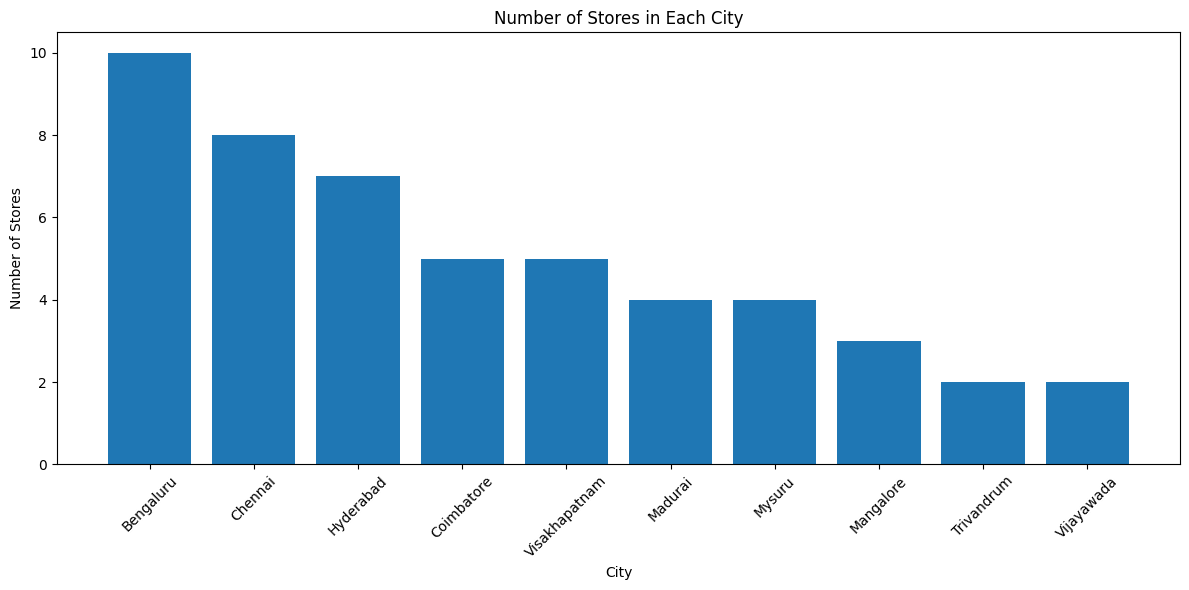

In [8]:
## creating a bar chart

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(city_store_count.index,city_store_count.values)

plt.title('Number of Stores in Each City')
plt.xlabel('City')
plt.ylabel('Number of Stores')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [9]:
## Identify the City with the Most Stores

city_with_most_stores = city_store_count.idxmax()
max_stores = city_store_count.max()

print("City with the most stores:", city_with_most_stores)
print("Number of stores:", max_stores)

City with the most stores: Bengaluru
Number of stores: 10


In [10]:
## Compare Bengaluru, Hyderabad, and Chennai

comparison = city_store_count[['Bengaluru', 'Hyderabad', 'Chennai']]
print(comparison)

city
Bengaluru    10
Hyderabad     7
Chennai       8
Name: store_id, dtype: int64


## INSIGHTS

City with most stores has the highest number of Nova Mart stores, indicating that it has the largest retail presence among the cities analyzed. The remaining cities have a comparatively lower number of stores, showing that the store network is unevenly distributed across locations. Bengaluru has X stores, compared with Y stores in Hyderabad and Z stores in Chennai.

## ** 2. Analyze Product Category Contribution to Sales During the Sankranti Campaign**

Analyze the **total quantity sold after the promotion** during the **Sankranti campaign** across different product categories.

###  Objective

In this analysis, we will:

-  Calculate the **total quantity sold after promotion** for each product category.
-  Calculate each category's **percentage contribution** to the overall quantity sold.
-  Create a **pie chart** to visualize the contribution of each product category.
-  Identify the product categories contributing the most and least to overall sales.
-  Generate insights based on the sales distribution across categories.

### 📐 Percentage Contribution Formula

$$
\text{Percentage Contribution} =
\frac{\text{Quantity Sold After Promotion for a Category}}
{\text{Total Quantity Sold After Promotion}}
\times 100
$$

### ** Key Questions**

- **Which product category contributed the most to overall sales?**
- **Which category contributed the least?**
- **What percentage of the total sales does each category represent?**
- **What business insights can be drawn from the distribution of sales across product categories?**

> ** Hint:** Use a **pie chart** to visualize the percentage contribution of each product category to the overall sales.

In [12]:
## Merging the required DataFrames

# Merge fact events with campaign information
events_data = df_fact_events.merge(df_camp[['campaign_id', 'campaign_name']],on='campaign_id',how='left')

# Merge product information to get category
events_data = events_data.merge(df_pro[['product_code', 'category']],on='product_code',how='left')

In [13]:
## Filtering the Sankranti campaign

sankranti_data = events_data[events_data['campaign_name'] == 'Sankranti']

In [14]:
## Calculating total quantity sold by category

category_sales = (sankranti_data.groupby('category')['quantity_sold(after_promo)'].sum().sort_values(ascending=False))
print(category_sales)

category
Grocery & Staples    177724
Home Appliances       35610
Home Care             16894
Combo1                12411
Personal Care          9430
Name: quantity_sold(after_promo), dtype: int64


In [15]:
## Calculating percentage contribution

category_percentage = (category_sales / category_sales.sum()) * 100
print(category_percentage.round(2))

category
Grocery & Staples    70.51
Home Appliances      14.13
Home Care             6.70
Combo1                4.92
Personal Care         3.74
Name: quantity_sold(after_promo), dtype: float64


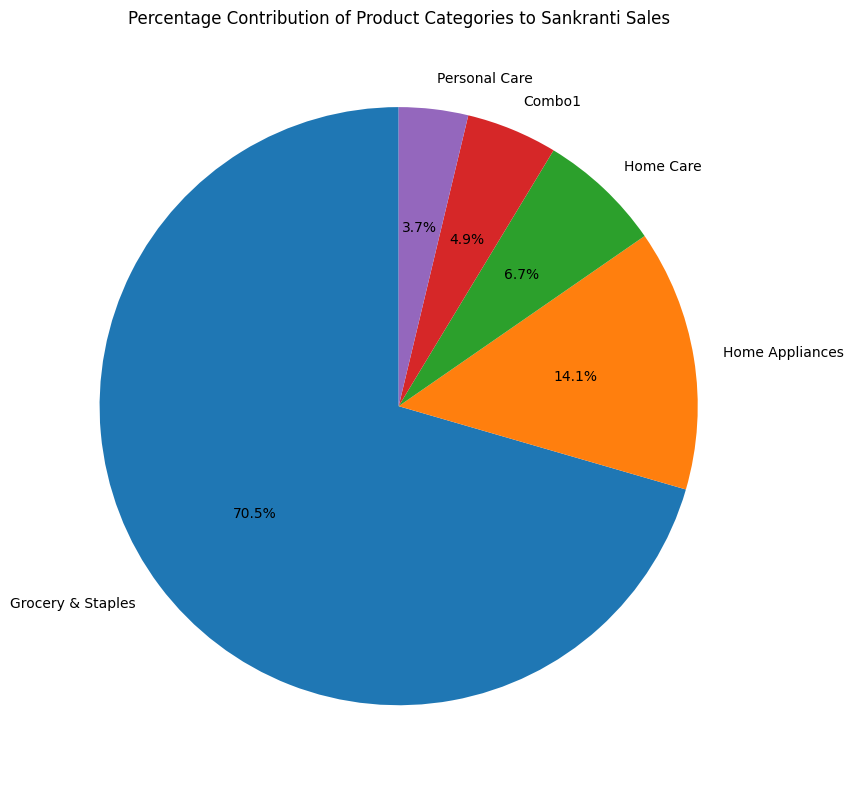

In [16]:
## Creating the Pie Chart

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
plt.pie(
    category_sales,
    labels=category_sales.index,
    autopct='%1.1f%%',
    startangle=90)

plt.title('Percentage Contribution of Product Categories to Sankranti Sales')
plt.tight_layout()
plt.show()

## INSIGHT
Grocery & Staples dominated the Sankranti campaign with a 70.51% contribution to total sales, followed by Home Appliances at 14.13%. Personal Care had the lowest contribution at 3.74%. The results indicate that the campaign's sales performance was heavily driven by the Grocery & Staples category.

## ** 3. Correlation Between Base Price and Sales Quantity After Promotion**

Examine the relationship between **base price after promotion** and **quantity sold after promotion** to understand whether changes in price are associated with changes in sales quantity.

###  Objective

In this analysis, we will:

-  Analyze `base_price(after_promo)`.
-  Analyze `quantity_sold(after_promo)`.
-  Calculate the **correlation** between price and sales quantity.
-  Use a **heatmap** to visualize the correlation.
-  Interpret the strength and direction of the relationship.

###  Correlation Interpretation

The correlation coefficient ranges from **-1 to +1**:

| Correlation | Interpretation |
|---|---|
| **+1** | Perfect positive relationship |
| **0** | No linear relationship |
| **-1** | Perfect negative relationship |

### ** Key Question**

**What insights can be drawn regarding the relationship between base price and sales quantities after the promotion?**

> ** Hint:** Use a **heatmap** to visualize the correlation between `base_price(after_promo)` and `quantity_sold(after_promo)`.

###  Business Insight

A **negative correlation** would indicate that higher prices tend to be associated with lower quantities sold, while a **positive correlation** would indicate that higher prices tend to be associated with higher quantities sold.

> ** Note:** Correlation indicates an association between the variables; it does **not** establish a causal relationship.

In [22]:
## Calculating the correlation

correlation = df_fact_events[['base_price(after_promo)', 'quantity_sold(after_promo)']].corr()
correlation

,base_price(after_promo),quantity_sold(after_promo)
base_price(after_promo),1.000000,0.269404
quantity_sold(after_promo),0.269404,1.000000


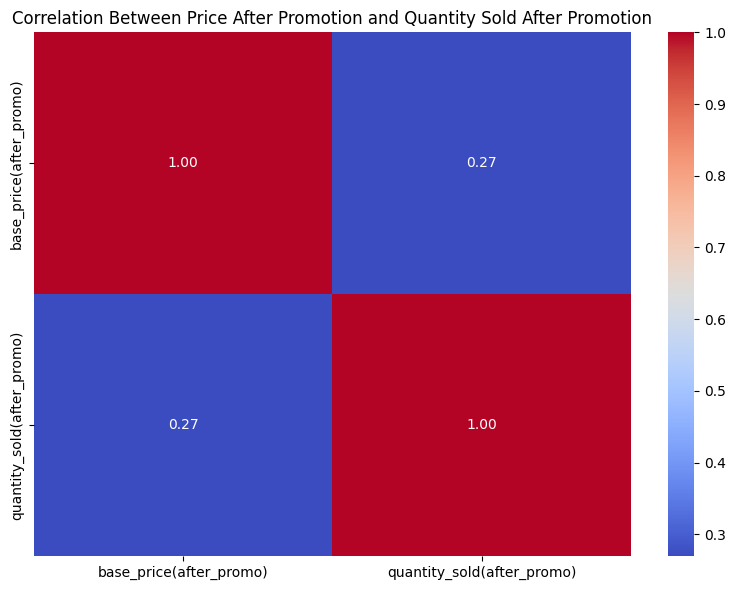

In [20]:
## Creating the Heatmap

import seaborn as sns
import matplotlib.pyplot as plt

correlation = df_fact_events[['base_price(after_promo)', 'quantity_sold(after_promo)']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f')

plt.title('Correlation Between Price After Promotion and Quantity Sold After Promotion')

plt.tight_layout()
plt.show()

## INSIGHT
There is a weak positive relationship (correlation = 0.269) between the base price after promotion and the quantity sold after promotion. This suggests that products with higher post-promotion prices tend to have slightly higher sales quantities, but the relationship is weak. Therefore, price alone does not strongly explain the variation in post-promotion sales quantities, and other factors such as product category, promotion type, product demand, and store location are likely influencing sales.

## ** 4. Distribution of Quantity Sold Before Promotion by Product Category**

Analyze the distribution of **quantity sold before the promotion** across different product categories, such as:

-  Grocery & Staples
-  Home Care
-  Personal Care
-  Home Appliances
-  Other Product Categories

###  Objective

In this analysis, we will:

-  Examine the distribution of `quantity_sold(before_promo)` for each product category.
-  Create **individual histograms** for each category.
-  Identify patterns, concentration, spread, and potential outliers in sales quantities.
-  Compare sales distributions across different product categories.
-  Use these patterns to identify opportunities for future promotional strategies.

### ** Key Questions**

- **Which product categories have the highest typical quantity sold before promotion?**
- **Which categories show greater variation in sales quantities?**
- **Are the distributions concentrated around specific quantity ranges?**
- **Are there any noticeable outliers or unusual sales patterns?**
- **How can these differences inform future promotional strategies?**

###  Business Interpretation

The distribution of pre-promotion sales can help identify **naturally high-performing and low-performing product categories**.

-  Categories with consistently high sales may respond well to **targeted promotions designed to maximize incremental revenue**.
-  Categories with low or widely dispersed sales may require **more targeted or category-specific promotional strategies**.
-  Categories with high variability may benefit from **store-level or product-level promotions** rather than a single strategy applied across the entire category.
-  Understanding the pre-promotion baseline is important when evaluating whether a promotion genuinely improves sales performance.

> ** Hint:** Use **individual histograms** to visualize the distribution of `quantity_sold(before_promo)` for each product category.

In [23]:
## Merging product category with sales data

events_data = df_fact_events.merge(df_pro[['product_code', 'category']],on='product_code',how='left')
print(events_data['category'].unique())

['Grocery & Staples' 'Home Care' 'Combo1' 'Home Appliances'
 'Personal Care']


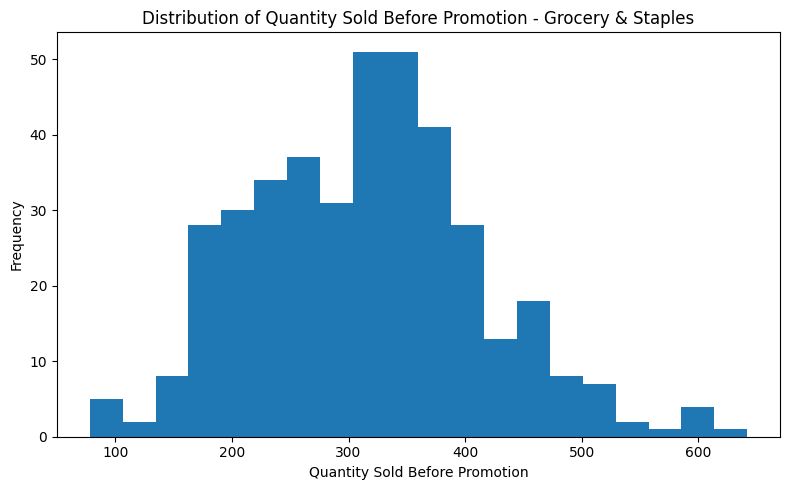

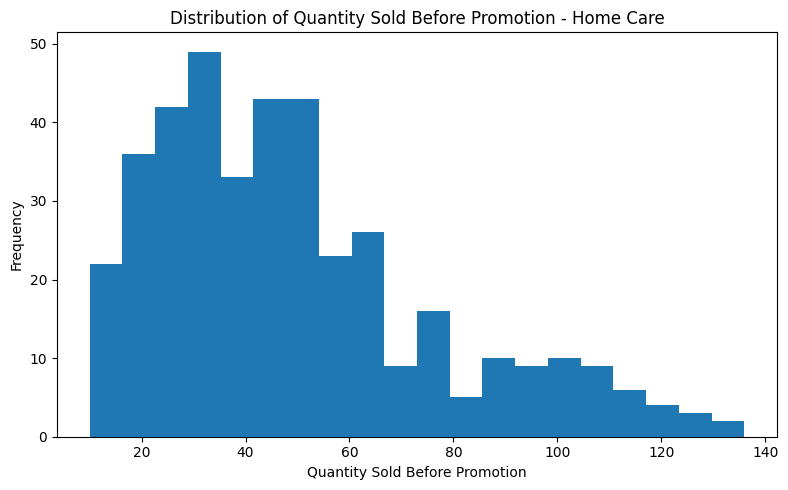

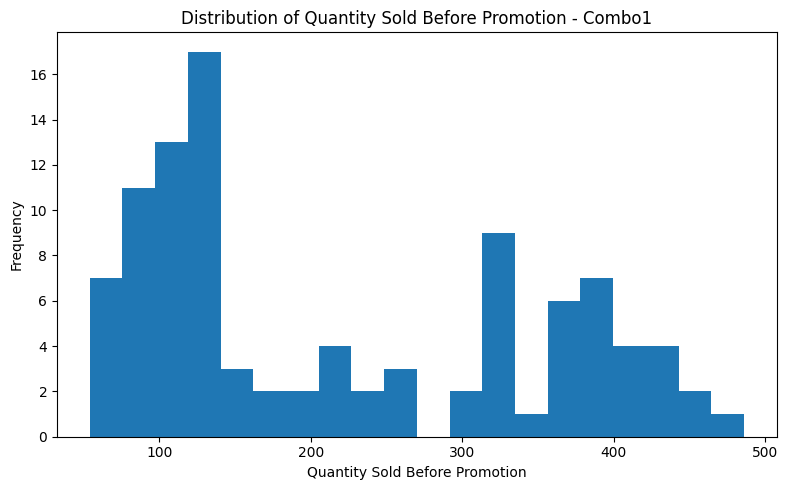

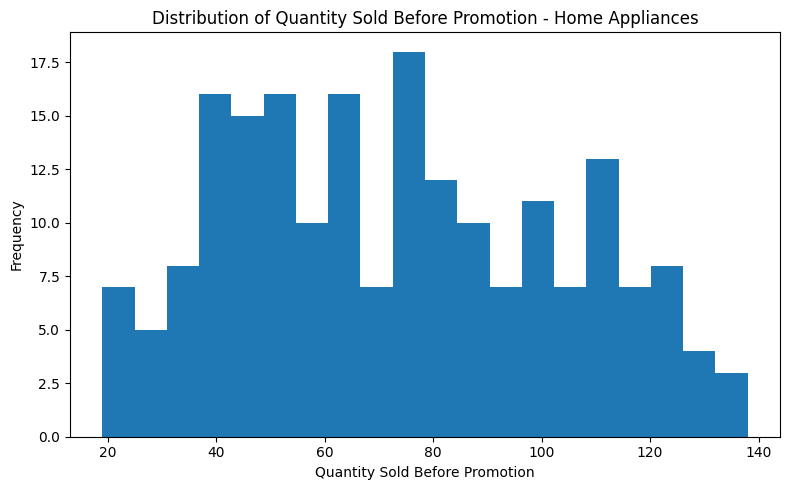

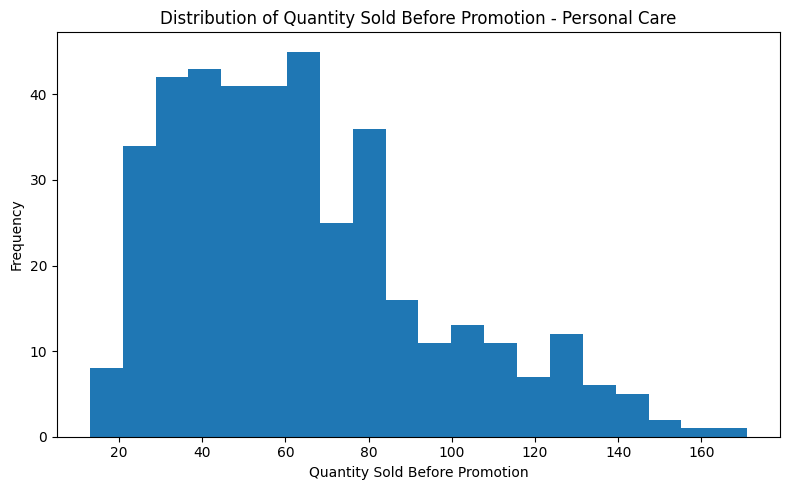

In [24]:
## Creating individual histograms

categories = events_data['category'].dropna().unique()

for category in categories:
    category_data = events_data[events_data['category'] == category]['quantity_sold(before_promo)']
    plt.figure(figsize=(8, 5))
    plt.hist(category_data,bins=20)
    
    plt.title(f'Distribution of Quantity Sold Before Promotion - {category}')
    
    plt.xlabel('Quantity Sold Before Promotion')
    plt.ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()

In [25]:
## Getting numerical statistics

category_stats = events_data.groupby('category')['quantity_sold(before_promo)'].agg(['count', 'mean', 'median', 'min', 'max', 'std'])
print(category_stats.round(2))

                   count    mean  median   min    max     std
category                                                     
Combo1               100  217.30   147.0  54.0  486.0  129.56
Grocery & Staples    400  314.79   317.0  78.0  642.0   99.00
Home Appliances      200   73.28    72.0  19.0  138.0   30.02
Home Care            400   49.58    43.0  10.0  136.0   27.33
Personal Care        400   63.78    58.0  13.0  171.0   31.23


## INSIGHTS
1. Grocery & Staples dominates baseline sales

Grocery & Staples has the highest mean quantity sold at 314.79 units and a median of 317 units.

The mean and median being very close suggests that the typical sales level is around 300+ units.

This indicates that Grocery & Staples has substantially stronger underlying demand than the other categories, even before promotions.

2. Combo1 has high variability

Combo1 has a mean of 217.30, but its median is only 147 and its standard deviation is 129.56, the highest among all categories.

The large difference between mean and median suggests that some products have exceptionally high baseline sales.

Combo1 appears to have an uneven demand pattern, with some products selling significantly more than others. Promotions should therefore potentially be targeted at individual products rather than treating the entire category uniformly.

3. Home Appliances has moderate and relatively stable demand

Home Appliances has:

Mean = 73.28
Median = 72
Std = 30.02

The mean and median are very close, indicating a relatively balanced distribution.

This suggests reasonably predictable baseline demand, which can help Nova Mart plan inventory and promotions more confidently.

4. Personal Care has lower baseline demand

Personal Care averages 63.78 units, with a median of 58.

Its standard deviation is 31.23, meaning there is some variation between products.

Promotions in Personal Care could focus on products with particularly low baseline sales to stimulate demand, while maintaining appropriate inventory for stronger sellers.

5. Home Care has the lowest baseline sales

Home Care has the lowest mean (49.58) and median (43) among the categories.

This suggests comparatively weaker baseline demand and could indicate an opportunity for targeted promotions, bundles, or improved product visibility.

## ** 5. Analyze Incremental Sold Units % (ISU%) Across Cities**

Analyze the **Incremental Sold Units Percentage (ISU%)** across different cities to evaluate how effectively promotions increased sales quantities in each location.

###  Objective

In this analysis, we will:

-  Calculate the **ISU% for each city**.
-  Compare the promotional impact across cities.
-  Identify the city with the **highest ISU%**.
-  Identify the city with the **smallest change in sales**.
-  Evaluate how effectively promotions are driving additional sales across different cities.

###  ISU% Formula

$$
ISU\% =
\frac{Quantity_{after} - Quantity_{before}}
{Quantity_{before}}
\times 100
$$

### ** Key Questions**

- **Which city recorded the highest ISU% after the promotion?**
- **Which city recorded the smallest change in sales?**
- **Which cities responded most strongly to the promotions?**
- **What trends can be observed regarding the effectiveness of promotions across cities?**

###  Business Interpretation

A **higher positive ISU%** indicates that promotions were more effective in increasing the quantity of products sold in that city.

A **low or negative ISU%** suggests that the promotion had limited impact or that sales quantities decreased after the promotion.

Comparing ISU% across cities can help identify **high-performing markets** where promotional strategies are effective and **underperforming markets** where promotions may need to be redesigned or better targeted.

> ** Hint:** Use a **line chart** to visualize and compare ISU% across cities.

In [26]:
## Merging store information

events_data = df_fact_events.merge(df_stores[['store_id', 'city']],on='store_id',how='left')

In [27]:
## Calculating total units before and after for each city

city_sales = events_data.groupby('city').agg(quantity_before=('quantity_sold(before_promo)', 'sum'),quantity_after=('quantity_sold(after_promo)', 'sum')).reset_index()
print(city_sales)

            city  quantity_before  quantity_after
0      Bengaluru          48972.0          105141
1        Chennai          39183.0           83273
2     Coimbatore          18200.0           38900
3      Hyderabad          34335.0           69399
4        Madurai          14086.0           31169
5      Mangalore           7454.0           14929
6         Mysuru          18202.0           37470
7     Trivandrum           4884.0           10170
8     Vijayawada           5297.0           11106
9  Visakhapatnam          17037.0           33916


In [28]:
## Calculating ISU%

city_sales['ISU%'] = ((city_sales['quantity_after'] - city_sales['quantity_before'])/ city_sales['quantity_before']) * 100
print(city_sales[['city', 'ISU%']].sort_values('ISU%', ascending=False))

            city        ISU%
4        Madurai  121.276445
0      Bengaluru  114.696153
2     Coimbatore  113.736264
1        Chennai  112.523288
8     Vijayawada  109.665849
7     Trivandrum  108.230958
6         Mysuru  105.856499
3      Hyderabad  102.123198
5      Mangalore  100.281728
9  Visakhapatnam   99.072607


In [31]:
## Finding highest and smallest ISU%

highest_ISU = city_sales.sort_values('ISU%',ascending=False).head(1)
smallest_ISU = city_sales.sort_values('ISU%',ascending=True).head(1)

print("City with highest ISU%:")
print(highest_ISU[['city', 'ISU%']])

print("\nCity with smallest ISU%:")
print(smallest_ISU[['city', 'ISU%']])

City with highest ISU%:
      city        ISU%
4  Madurai  121.276445

City with smallest ISU%:
            city       ISU%
9  Visakhapatnam  99.072607


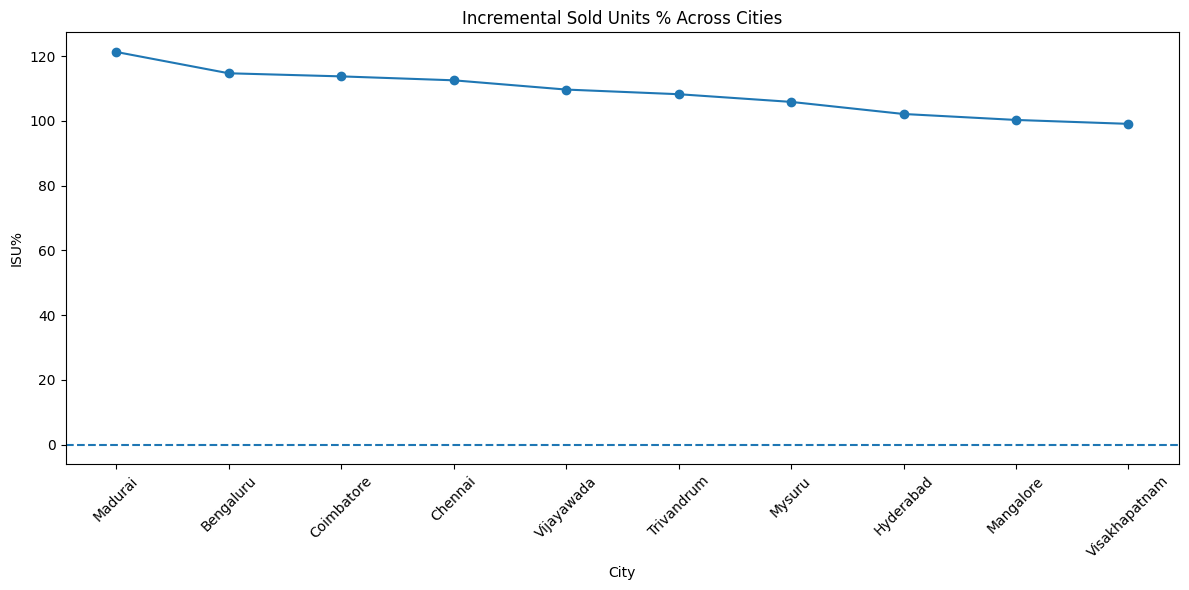

In [32]:
## Creating the Line Chart

city_sales = city_sales.sort_values('ISU%', ascending=False)

plt.figure(figsize=(12, 6))
plt.plot(
    city_sales['city'],
    city_sales['ISU%'],
    marker='o')

plt.title('Incremental Sold Units % Across Cities')
plt.xlabel('City')
plt.ylabel('ISU%')

plt.xticks(rotation=45)
plt.axhline(y=0, linestyle='--')

plt.tight_layout()
plt.show()

## INSIGHTS


1. Madurai recorded the highest ISU% at 121.28%, meaning the quantity sold after promotion was more than double the quantity sold before promotion.
2. Bengaluru ranked second with an ISU% of 114.70%.
3. Coimbatore and Chennai also showed strong improvements, with ISU% of 113.74% and 112.52%, respectively.
4. Visakhapatnam recorded the smallest change at 99.07%. Despite being the lowest among the cities, it still represents a very substantial increase in units sold.
5. Mangalore had an ISU% of 100.28%, while Hyderabad recorded 102.12%.
6. The relatively narrow range from 99.07% to 121.28% suggests that promotions increased sales substantially across the entire city network rather than being effective in only a few locations.

## ** 6. Relationship Between Incremental Revenue and Incremental Sold Units in Hyderabad**

Analyze the relationship between **Incremental Revenue Percentage (IR%)** and **Incremental Sold Units Percentage (ISU%)** for different promotion types in **Hyderabad**.

###  Objective

In this analysis, we will:

-  Filter the data for **Hyderabad**.
-  Compare different **promotion types**.
-  Calculate and analyze **Incremental Revenue % (IR%)**.
-  Calculate and analyze **Incremental Sold Units % (ISU%)**.
-  Use a **scatter plot** to examine the relationship between IR% and ISU%.
-  Identify the promotion type with the **highest ISU%**.
-  Identify the promotion type with the **highest IR%**.
-  Evaluate the balance between revenue growth and unit-sales growth.

### ** Key Questions**

- **Which promotion type led to the highest Incremental Sold Units %?**
- **Which promotion type generated the highest Incremental Revenue %?**
- **Is there a clear relationship between IR% and ISU% across promotion types?**
- **Which promotion types provide the best balance between increasing sales volume and revenue?**

###  Visualization

> ** Hint:** Use a **scatter plot** with **ISU% on the X-axis** and **IR% on the Y-axis** to analyze the relationship between the two metrics.

###  Business Interpretation

A promotion type with **high ISU% and high IR%** can be considered particularly effective because it increases both **sales volume and revenue**.

A promotion with **high ISU% but relatively low or negative IR%** may increase sales volume without generating proportional revenue growth.

Conversely, a promotion with **high IR% but lower ISU%** may be more effective at generating revenue without substantially increasing the number of units sold.

This comparison can help the business identify promotion types that provide the **best overall commercial impact in Hyderabad**.

In [33]:
## Merging store information

events_data = df_fact_events.merge(df_stores[['store_id', 'city']],on='store_id',how='left')

In [34]:
## Filtering Hyderabad

hyderabad_data = events_data[events_data['city'] == 'Hyderabad'].copy()

In [35]:
## Calculating revenue before and after

hyderabad_data['revenue_before'] = (hyderabad_data['base_price(before_promo)'] *hyderabad_data['quantity_sold(before_promo)'])

hyderabad_data['revenue_after'] = (hyderabad_data['base_price(after_promo)'] *hyderabad_data['quantity_sold(after_promo)'])

In [36]:
## Aggregating by promo type

promo_performance = hyderabad_data.groupby('promo_type').agg(
    revenue_before=('revenue_before', 'sum'),
    revenue_after=('revenue_after', 'sum'),
    quantity_before=('quantity_sold(before_promo)', 'sum'),
    quantity_after=('quantity_sold(after_promo)', 'sum')
).reset_index()

In [37]:
## Calculating IR% and ISU%

promo_performance['IR%'] = ((promo_performance['revenue_after'] - promo_performance['revenue_before'])/ promo_performance['revenue_before']) * 100

promo_performance['ISU%'] = ((promo_performance['quantity_after'] - promo_performance['quantity_before'])/ promo_performance['quantity_before']) * 100

print(promo_performance[['promo_type', 'IR%', 'ISU%']].round(2))

     promo_type     IR%    ISU%
0       25% OFF  -34.77  -12.90
1       33% OFF   -2.98   45.17
2       50% OFF  -31.99   35.94
3  500 Cashback  122.82  167.38
4         BOGOF   74.12  252.83


In [38]:
## Identifing the highest values

highest_ISU = promo_performance.sort_values('ISU%',ascending=False).head(1)

highest_IR = promo_performance.sort_values('IR%',ascending=False).head(1)

print("Highest Incremental Sold Units:")
print(highest_ISU[['promo_type', 'ISU%']].round(2))

print("\nHighest Incremental Revenue:")
print(highest_IR[['promo_type', 'IR%']].round(2))

Highest Incremental Sold Units:
  promo_type    ISU%
4      BOGOF  252.83

Highest Incremental Revenue:
     promo_type     IR%
3  500 Cashback  122.82


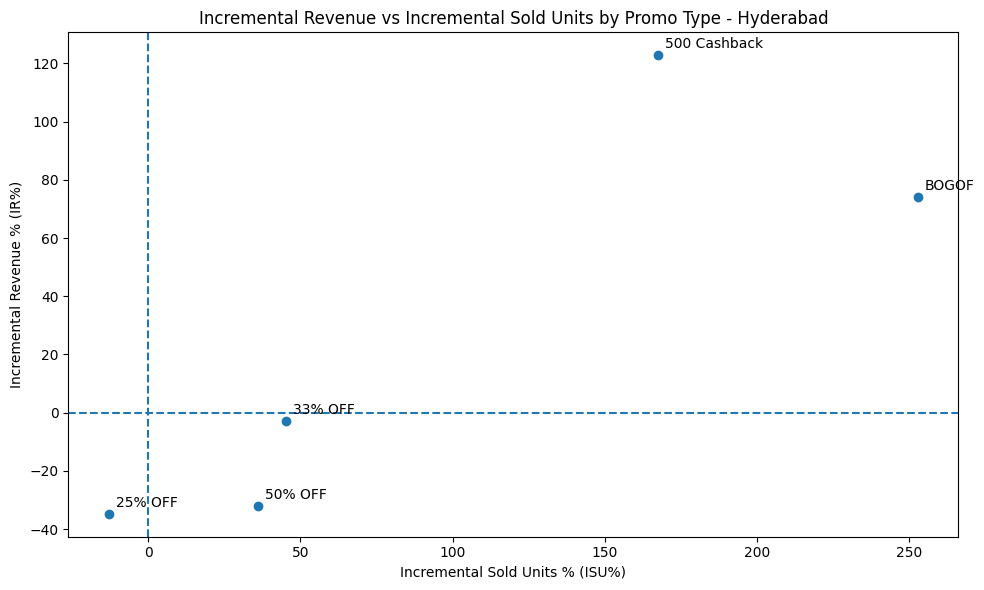

In [39]:
## Scatter Plot

plt.figure(figsize=(10, 6))

plt.scatter(promo_performance['ISU%'],promo_performance['IR%'])

for _, row in promo_performance.iterrows():
    plt.annotate(
        row['promo_type'],
        (row['ISU%'], row['IR%']),
        xytext=(5, 5),
        textcoords='offset points')

plt.axhline(0, linestyle='--')
plt.axvline(0, linestyle='--')

plt.title('Incremental Revenue vs Incremental Sold Units by Promo Type - Hyderabad')
plt.xlabel('Incremental Sold Units % (ISU%)')
plt.ylabel('Incremental Revenue % (IR%)')

plt.tight_layout()
plt.show()

## INSIGHTS
1. Highest Incremental Sold Units — BOGOF

BOGOF recorded the highest ISU%:

ISU% = 252.83%

This means BOGOF generated the strongest increase in units sold among the promotion types in Hyderabad.

2. Highest Incremental Revenue — 500 Cashback

500 Cashback generated the highest IR%:

IR% = 122.82%

It also produced a very strong ISU% of 167.38%, meaning it wasn't just generating revenue—it was also substantially increasing sales volume.

3. Important trade-off

The most interesting comparison is between BOGOF and 500 Cashback:

BOGOF: ISU = 252.83%, IR = 74.12%
500 Cashback: ISU = 167.38%, IR = 122.82%

BOGOF is much stronger at driving units, while 500 Cashback is stronger at generating revenue.

This suggests BOGOF may encourage customers to purchase substantially more units, while Cashback achieves a better balance between increased volume and revenue.

4. 33% OFF and 50% OFF

Both increased unit sales:

33% OFF → 45.17% ISU
50% OFF → 35.94% ISU

However, both had negative IR%:

33% OFF → -2.98%
50% OFF → -31.99%

This indicates that the additional units sold weren't sufficient to compensate for the revenue reduction caused by the discounts.

Interestingly, 50% OFF performs worse than 33% OFF on both metrics, suggesting that the deeper discount did not translate into proportionally greater sales volume.

5. 25% OFF performed poorly

25% OFF is the only promotion where both metrics are negative:

IR% = -34.77%
ISU% = -12.90%

Therefore, this promotion appears ineffective in Hyderabad based on both revenue and sales volume.

## BUSINESS INSIGHTS

In Hyderabad, BOGOF generated the highest incremental sold units (252.83%), while 500 Cashback generated the highest incremental revenue (122.82%). BOGOF was particularly effective at driving sales volume, whereas 500 Cashback provided a better balance between revenue and volume growth. In contrast, 33% OFF and 50% OFF increased unit sales but resulted in negative incremental revenue, indicating that the discounts reduced revenue despite higher sales volumes. 25% OFF performed poorly on both metrics, with negative IR% and ISU%. Overall, BOGOF and 500 Cashback appear to be the most effective promotional strategies for Hyderabad, depending on whether the priority is maximizing volume or revenue.

## ** 7. Revenue Before vs After Promotions Across Product Categories in Bengaluru**

Analyze the **revenue before and after promotions** across different product categories in **Bengaluru** to understand how promotions influenced overall revenue performance.

###  Objective

In this analysis, we will:

-  Filter the data for **Bengaluru**.
-  Group the data by **product category**.
-  Calculate the **total revenue before promotion** for each category.
-  Calculate the **total revenue after promotion** for each category.
-  Compare revenue before and after promotions.
-  Identify categories that experienced the largest increase or decrease in revenue.
-  Evaluate the overall impact of promotions on revenue in Bengaluru.

###  Revenue Calculation

####  Revenue Before Promotion

$$
Revenue_{before}
=
Base\ Price_{before\ promo}
\times
Quantity\ Sold_{before\ promo}
$$

#### Revenue After Promotion

$$
Revenue_{after}
=
Base\ Price_{after\ promo}
\times
Quantity\ Sold_{after\ promo}
$$

### ** Key Questions**

- **Which product categories generated the highest revenue before and after promotions?**
- **Which categories experienced the greatest increase in revenue?**
- **Did promotions increase or decrease revenue across the categories?**
- **What was the overall impact of promotions on revenue in Bengaluru?**
- **Are there any categories where revenue declined despite the promotion?**

###  Visualization

> ** Hint:** Use a **vertical bar chart** to compare `Revenue Before` and `Revenue After` for each product category.

###  Business Interpretation

Comparing revenue before and after promotions helps identify which product categories **benefited most from promotional campaigns**.

-  **Higher revenue after promotion** → Promotion may have positively impacted revenue.
-  **Lower revenue after promotion** → Promotion may have reduced revenue or failed to generate sufficient additional sales.
-  **Large differences between categories** → Promotional effectiveness varies by product category.
-  Categories showing strong post-promotion revenue growth may be candidates for **future promotional investment**.

The overall comparison will help determine whether promotions **improved total revenue in Bengaluru** and which product categories contributed most to that change.

In [41]:
## Merging store and product information

events_data = df_fact_events.merge(df_stores[['store_id', 'city']],on='store_id',how='left')

events_data = events_data.merge(df_pro[['product_code', 'category']],on='product_code',how='left')

In [42]:
## Filtering Bengaluru

bengaluru_data = events_data[events_data['city'] == 'Bengaluru'].copy()

In [43]:
## Calculating revenue before and after promotion

bengaluru_data['revenue_before'] = (bengaluru_data['base_price(before_promo)'] *bengaluru_data['quantity_sold(before_promo)'])

bengaluru_data['revenue_after'] = (bengaluru_data['base_price(after_promo)'] *bengaluru_data['quantity_sold(after_promo)'])

In [44]:
## Aggregating revenue by category

category_revenue = bengaluru_data.groupby('category').agg(revenue_before=('revenue_before', 'sum'),revenue_after=('revenue_after', 'sum')).reset_index()
print(category_revenue)

            category  revenue_before  revenue_after
0             Combo1      15777000.0       38125000
1  Grocery & Staples      12262460.0       13861259
2    Home Appliances       2188810.0        4122680
3          Home Care       2104460.0        3180020
4      Personal Care        576321.0         389629


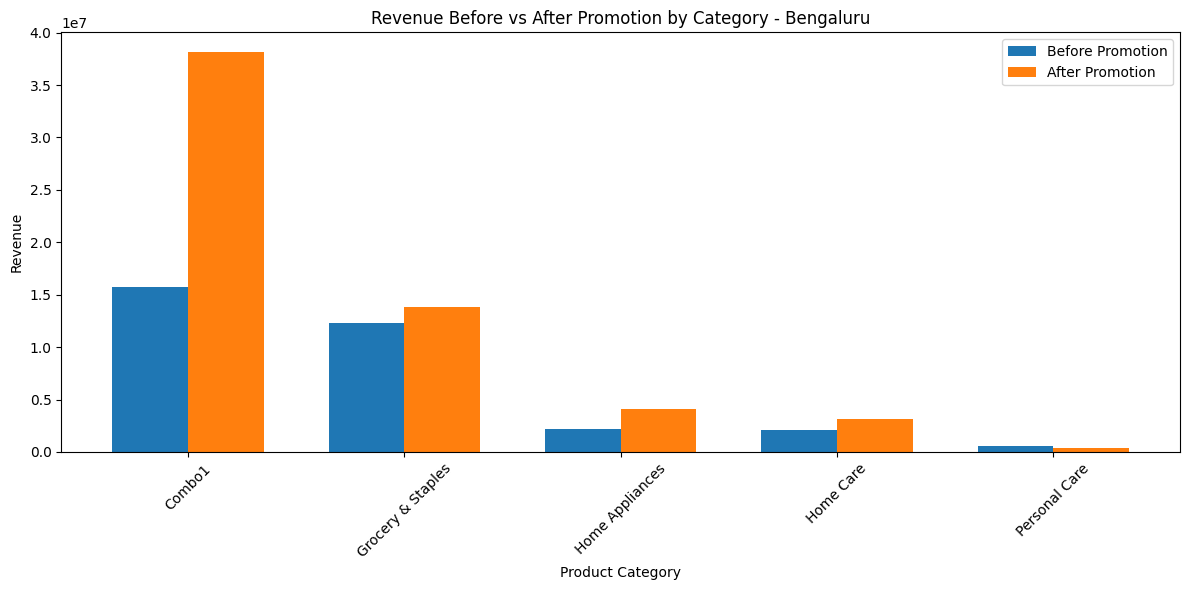

In [45]:
## Creating the Vertical Bar Chart

x = np.arange(len(category_revenue))
width = 0.35
plt.figure(figsize=(12, 6))

plt.bar(
    x - width/2,
    category_revenue['revenue_before'],
    width,
    label='Before Promotion')

plt.bar(
    x + width/2,
    category_revenue['revenue_after'],
    width,
    label='After Promotion')

plt.title('Revenue Before vs After Promotion by Category - Bengaluru')
plt.xlabel('Product Category')
plt.ylabel('Revenue')

plt.xticks(x,category_revenue['category'],rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## INSIGHTS

Key observations

1. Combo1 was the strongest performer

Combo1 revenue increased from 15.78 million to 38.13 million, an increase of approximately 22.35 million.

That's by far the largest absolute revenue increase among the categories.

2. Home Appliances also performed strongly

Revenue increased from 2.19 million to 4.12 million, almost doubling compared with the pre-promotion revenue.

3. Grocery & Staples showed moderate growth

Revenue increased from 12.26 million to 13.86 million. Although the absolute increase is smaller than Combo1 and Home Appliances, Grocery & Staples already had a relatively high baseline revenue.

4. Home Care improved

Revenue increased from 2.10 million to 3.18 million, indicating a positive promotional impact.

5. Personal Care was the only declining category

Revenue decreased from 576,321 to 389,629, a decline of 186,692.

This suggests that the promotions used for Personal Care did not generate enough additional sales volume to compensate for the reduction in promotional pricing.

##  BUSINESS INSIHTS

Promotions had a strongly positive impact on overall revenue in Bengaluru. Revenue increased from approximately ₹32.31 million before the promotions to ₹59.42 million after the promotions, representing an increase of about 83.90%. Combo1 was the strongest contributor, with revenue increasing by approximately ₹22.35 million. Home Appliances and Home Care also showed substantial growth, while Grocery & Staples experienced moderate growth. Personal Care was the only category to experience a revenue decline, suggesting that its promotional strategy may need to be reviewed. Overall, the promotions were highly effective in increasing revenue in Bengaluru, although category-specific strategies may be required to improve underperforming segments.